# Restaurant demand forecasting — Layer 1 prototype

Goal: predict daily units sold **per menu item**, which is the foundation for:
- the sales forecast dashboard (aggregate this across items)
- the ingredient demand forecast (multiply this by the recipe/BOM table)

This notebook uses **synthetic data** so you can validate the whole pipeline
before wiring it into the FastAPI service. Swap `daily_item_sales.csv` for
real (or POS-exported) data later — nothing else below needs to change.

In [1]:
import pandas as pd 
from sqlalchemy import create_engine
import numpy as np

In [2]:
import datetime

In [3]:
USER = 'postgres'
PASSWORD = 'Anyasam101'
HOST = 'Localhost'
PORT = '5432'
DB_NAME = 'MONGA'

connection_string = f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"
engine = create_engine(connection_string)

query = """
SELECT 
    c.calendar_date,
    o.store_id,
    mi.item_id,
    mi.category,
    mi.item_name,
    COALESCE(SUM(oi.quantity), 0) AS quantity
FROM calendar_dim c
CROSS JOIN menu_items mi
LEFT JOIN orders o ON o.order_timestamp::date = c.calendar_date
LEFT JOIN order_items oi ON oi.order_id = o.order_id AND oi.item_id = mi.item_id
WHERE mi.item_id NOT LIKE 'M%%'
GROUP BY c.calendar_date, o.store_id, mi.item_id, mi.item_name
ORDER BY mi.item_id, c.calendar_date;
"""

In [4]:
try:
    df = pd.read_sql(query, con=engine)
    print(f"Successfully loaded {len(df)} rows.")

    # index=False prevents pandas from writing a row-number column into the CSV
    output_file = "data/extracted_data.csv"
    df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Data successfully saved to {output_file}")
except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # 6. Dispose of the engine connection pool
    engine.dispose()

Successfully loaded 301644 rows.
Data successfully saved to data/extracted_data.csv


In [5]:
items = df[~df['item_id'].str.contains('M')][['item_id', 'item_name']]
item_ids = items.drop_duplicates(subset=['item_id'], keep='first')

item_dict = df.set_index('item_name')['item_id'].to_dict()

def id_correction(row):
    return item_dict[row['item_name']]

df['item_id'] = df.apply(id_correction, axis=1)

df.to_csv('data/cleaned_extracted_data.csv', index=False)

In [6]:
df.head()

,calendar_date,store_id,item_id,category,item_name,quantity
0,2022-01-01,STR_02,SKU_01,Signature Chicken,The King,0
1,2022-01-01,STR_03,SKU_01,Signature Chicken,The King,0
2,2022-01-01,STR_01,SKU_01,Signature Chicken,The King,2
3,2022-01-02,STR_03,SKU_01,Signature Chicken,The King,2
4,2022-01-02,STR_02,SKU_01,Signature Chicken,The King,1


### Engineering features


In [7]:
# Convert to datetime
df['calendar_date'] = pd.to_datetime(df['calendar_date'])
df['date'] = df['calendar_date'].dt.date
# Group by item to create time-series window features
grouped = df.groupby(['store_id', 'item_id'])['quantity']

df['lag_1'] = grouped.shift(1)
df['lag_7'] = grouped.shift(7)
df['lag_14'] = grouped.shift(14)
df['rolling_mean_7'] = grouped.transform(lambda x: x.rolling(7, min_periods=1).mean()).round(2)

# Date Features
df['day_of_week'] = df['calendar_date'].dt.dayofweek + 1  # 1=Mon, 7=Sun (ISODOW)
df['month'] = df['calendar_date'].dt.month
df['is_weekend'] = df['calendar_date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_payday'] = df['calendar_date'].dt.day.isin([15, 30, 31]).astype(int)

# df = df.replace(np.nan, 0)
df.head()

,calendar_date,store_id,item_id,category,item_name,quantity,date,lag_1,lag_7,lag_14,rolling_mean_7,day_of_week,month,is_weekend,is_payday
0,2022-01-01,STR_02,SKU_01,Signature Chicken,The King,0,2022-01-01,NaN,NaN,NaN,0.0,6,1,1,0
1,2022-01-01,STR_03,SKU_01,Signature Chicken,The King,0,2022-01-01,NaN,NaN,NaN,0.0,6,1,1,0
2,2022-01-01,STR_01,SKU_01,Signature Chicken,The King,2,2022-01-01,NaN,NaN,NaN,2.0,6,1,1,0
3,2022-01-02,STR_03,SKU_01,Signature Chicken,The King,2,2022-01-02,0.0,NaN,NaN,1.0,7,1,1,0
4,2022-01-02,STR_02,SKU_01,Signature Chicken,The King,1,2022-01-02,0.0,NaN,NaN,0.5,7,1,1,0


### I realized seedfast created duplicate items with different ids, so I'll now try to map every item with the corresponing proper id 'SKU-x'

### Training the lightgbm model

In [8]:
import lightgbm as lgb

cutoff_date = datetime.date(2026, 7, 1)
df["item_id"] = df["item_id"].astype("category")
df["store_id"] = df["store_id"].astype("category")
df["category"] = df["category"].astype("category")

FEATURES = ["item_id", "store_id", "category", "day_of_week", "is_weekend", "month",
            "lag_1", "lag_7", "lag_14", "rolling_mean_7", "is_payday"]
TARGET = "quantity"
                        
cutoff_date = df["date"].max() - pd.Timedelta(days=21)
train = df[df["date"] <= cutoff_date]
test = df[df["date"] > cutoff_date].copy()

train_set = lgb.Dataset(train[FEATURES], label=train[TARGET], categorical_feature=["item_id", "store_id", "category"])
params = {"objective": "regression", "metric": "mae", "learning_rate": 0.05, "num_leaves": 31, "verbose": -1}
model = lgb.train(params, train_set, num_boost_round=300)

### Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error

test["predicted"] = model.predict(test[FEATURES]).clip(min=0)

overall_mae = mean_absolute_error(test[TARGET], test["predicted"])
overall_mape = (np.abs(test[TARGET] - test["predicted"]) / test[TARGET].replace(0, np.nan)).mean() * 100
print(f"Overall MAE:  {overall_mae:.2f} units/day")
print(f"Overall MAPE: {overall_mape:.1f}%")

per_item = (test.groupby("item_name")
            .apply(lambda g: (np.abs(g[TARGET] - g['predicted']) / g[TARGET].replace(0, np.nan)).mean() * 100)
            .sort_values())
per_item.round(1)

Overall MAE:  0.98 units/day
Overall MAPE: 48.2%


item_name
Saver Meal A Junior                        36.5
Lychee Fruit Tea (M)                       37.8
Green Dragon Milk Tea (M)                  39.0
Lychee Fruit Tea (L)                       39.1
Taiker                                     39.2
Monga Salad Ala Carte                      39.7
Hot Chick                                  39.8
Oolong Sea Salt Foam (M)                   40.7
Green Dragon Milk Tea (L)                  41.1
Saver Meal B (1 Chop & Fries)              41.3
Saver Meal C Junior Chop & Pasta           41.3
Fire Dragon Milk Tea (L)                   41.8
Black Dragon Boba                          42.1
Soup                                       42.6
Dark Choco Sea Salt Foam (M)               42.8
Orange Fruit Tea (L)                       42.8
Saver Meal D (2 Crispy Chicken & Rice)     43.7
Chicken Nuggets Noodles                    43.7
Bottled Water                              43.9
Chicken Chops Congee                       44.0
Black Dragon Milk Tea (L)     

### Plot actual vs predicted

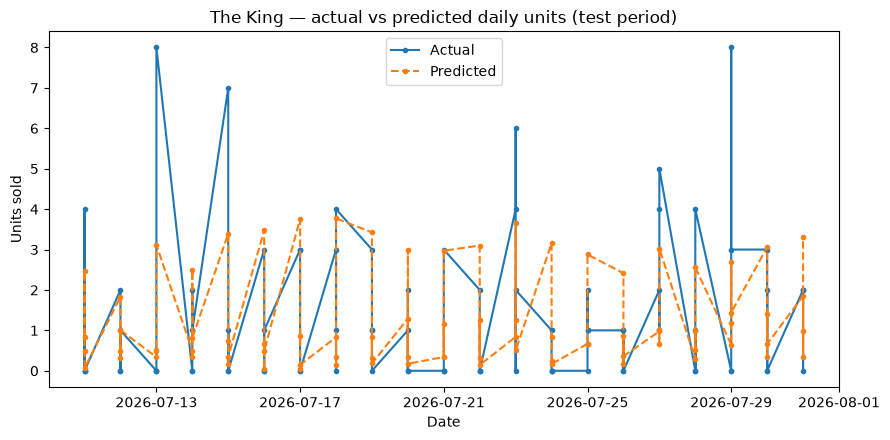

In [10]:
import matplotlib.pyplot as plt

item = "The King"  # try swapping this for any item_name in the menu
sub = test[test["item_name"] == item].sort_values("date")

plt.figure(figsize=(9, 4.5))
plt.plot(sub["date"], sub["quantity"], label="Actual", marker="o", markersize=3)
plt.plot(sub["date"], sub["predicted"], label="Predicted", linestyle="--", marker="o", markersize=3)
plt.title(f"{item} — actual vs predicted daily units (test period)")
plt.xlabel("Date"); plt.ylabel("Units sold"); plt.legend(); plt.tight_layout()
plt.show()

In [11]:
rn = 60
rm = rn + 5

actual_value = test.loc[test.index[rn:rm]]['quantity']
# # df.loc[0, FEATURES]
actual_value
predicted_value = model.predict(test.loc[test.index[[rn]], FEATURES])
# print(test.loc[test.index[[rn]], FEATURES])
print(f'Actual Value: \n{actual_value}')
print(f'Predicted Value: {predicted_value}')

# test.loc[[test.index[0]], FEATURES]

Actual Value: 
5268    1
5269    0
5270    1
5271    0
5272    2
Name: quantity, dtype: int64
Predicted Value: [0.85160124]


## Function to make a forecast of the quantity for an item, or eventually for each item ;)

In [12]:
df.head()

,calendar_date,store_id,item_id,category,item_name,quantity,date,lag_1,lag_7,lag_14,rolling_mean_7,day_of_week,month,is_weekend,is_payday
0,2022-01-01,STR_02,SKU_01,Signature Chicken,The King,0,2022-01-01,NaN,NaN,NaN,0.0,6,1,1,0
1,2022-01-01,STR_03,SKU_01,Signature Chicken,The King,0,2022-01-01,NaN,NaN,NaN,0.0,6,1,1,0
2,2022-01-01,STR_01,SKU_01,Signature Chicken,The King,2,2022-01-01,NaN,NaN,NaN,2.0,6,1,1,0
3,2022-01-02,STR_03,SKU_01,Signature Chicken,The King,2,2022-01-02,0.0,NaN,NaN,1.0,7,1,1,0
4,2022-01-02,STR_02,SKU_01,Signature Chicken,The King,1,2022-01-02,0.0,NaN,NaN,0.5,7,1,1,0


In [13]:
df[df['item_name'] == 'The King'].iloc[0]

calendar_date     2022-01-01 00:00:00
store_id                       STR_02
item_id                        SKU_01
category            Signature Chicken
item_name                    The King
quantity                            0
date                       2022-01-01
lag_1                             NaN
lag_7                             NaN
lag_14                            NaN
rolling_mean_7                    0.0
day_of_week                         6
month                               1
is_weekend                          1
is_payday                           0
Name: 0, dtype: object

In [14]:
df[(df['item_name'] == 'The King') & (df['store_id'] == 'STR_02')]

,calendar_date,store_id,item_id,category,item_name,quantity,date,lag_1,lag_7,lag_14,rolling_mean_7,day_of_week,month,is_weekend,is_payday
0,2022-01-01,STR_02,SKU_01,Signature Chicken,The King,0,2022-01-01,NaN,NaN,NaN,0.00,6,1,1,0
4,2022-01-02,STR_02,SKU_01,Signature Chicken,The King,1,2022-01-02,0.0,NaN,NaN,0.50,7,1,1,0
6,2022-01-03,STR_02,SKU_01,Signature Chicken,The King,1,2022-01-03,1.0,NaN,NaN,0.67,1,1,0,0
9,2022-01-04,STR_02,SKU_01,Signature Chicken,The King,2,2022-01-04,1.0,NaN,NaN,1.00,2,1,0,0
14,2022-01-05,STR_02,SKU_01,Signature Chicken,The King,0,2022-01-05,2.0,NaN,NaN,0.80,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5274,2026-07-27,STR_02,SKU_01,Signature Chicken,The King,4,2026-07-27,0.0,1.0,0.0,0.86,1,7,0,0
5276,2026-07-28,STR_02,SKU_01,Signature Chicken,The King,0,2026-07-28,4.0,0.0,1.0,0.86,2,7,0,0
5281,2026-07-29,STR_02,SKU_01,Signature Chicken,The King,3,2026-07-29,0.0,0.0,0.0,1.29,3,7,0,0
5286,2026-07-30,STR_02,SKU_01,Signature Chicken,The King,2,2026-07-30,3.0,0.0,0.0,1.57,4,7,0,1


In [15]:
df['category'].cat.categories

Index(['Add Ons', 'Burgers & Salads', 'Congee', 'Drinks', 'Monga Bites',
       'Noodles', 'Saver Meals', 'Signature Chicken'],
      dtype='str')

## Function to calculate the predicted demand of each item per store using the model (Short Horizon Path)

In [16]:
lead_time = 28
stock_period = 60
forecast_duration = 14
# forecast_duration = lead_time + stock_period
stock_date = df['calendar_date'].max()
cutoff_date = stock_date - pd.Timedelta(days=30)

def forecast_item(features):
    for col in ["item_id", "store_id", "category"]:
        features[col] = pd.Categorical(features[col], categories=df[col].cat.categories)
    predicted_qty = model.predict(features[FEATURES])
    return float(predicted_qty[0])

def predict_qty(item_name, store_id):
    sim = df[(df['item_name'] == item_name) &
             (df['store_id'] == store_id) &
             (df['calendar_date'] >= cutoff_date)].reset_index(drop=True)

    item_data = df[df['item_name'] == item_name].iloc[0]
    item_id = item_data['item_id']
    category = item_data['category']
    latest_date = sim['calendar_date'].max()

    for i in range(forecast_duration):
        latest_date += pd.Timedelta(days=1)

        qty = sim['quantity']
        lag_1 = qty.iloc[-1]
        lag_7 = qty.iloc[-7] if len(qty) >= 7 else np.nan
        lag_14 = qty.iloc[-14] if len(qty) >= 14 else np.nan
        rolling_mean_7 = np.round(qty.tail(7).mean(), 2)

        day_of_week = latest_date.isoweekday()
        is_weekend = 1 if day_of_week in [6, 7] else 0
        is_payday = 1 if latest_date.day in [15, 30, 31] else 0

        features = pd.DataFrame([{
            'lag_1': lag_1, 'lag_7': lag_7, 'lag_14': lag_14,
            'rolling_mean_7': rolling_mean_7,
            'day_of_week': day_of_week, 'month': latest_date.month,
            'is_weekend': is_weekend, 'is_payday': is_payday,
            'category': category, 'item_id': item_id, 'store_id': store_id
        }])
        predicted_qty = forecast_item(features)

        new_row = pd.DataFrame([{
            'item_id': item_id, 'item_name': item_name,
            'calendar_date': latest_date, 'store_id': store_id,
            'category': category, 'date': latest_date.date(),
            'day_of_week': day_of_week, 'month': latest_date.month,
            'is_weekend': is_weekend, 'is_payday': is_payday,
            'lag_1': lag_1, 'lag_7': lag_7, 'lag_14': lag_14,
            'rolling_mean_7': rolling_mean_7,
            'quantity': predicted_qty,
        }])


        sim = pd.concat([sim, new_row], ignore_index=True)

    # Cutoff with no lead time
    predicted_total_ty = sim[sim['calendar_date'] >= stock_date]['quantity'].sum(axis=0)

    return predicted_total_ty

predict_qty('The King', 'STR_01')

# test_df = df[(df['item_name'] == 'The King') & (df['store_id'] == 'STR_02') & (df['calendar_date'] >= cutoff_date)]


np.float64(13.91526724982261)

## Predicted amount of whole item, not taking into account yet ingredient and bill of materials

In [17]:
print(f'Predicted The King demand for STR_01: {predict_qty('The King', 'STR_01')}\n')
print(f'Predicted The King demand for STR_02: {predict_qty('The King', 'STR_02')}\n')
print(f'Predicted The King demand for STR_03: {predict_qty('The King', 'STR_03')}\n')
print(f'Predicted The King demand for STR_04: {predict_qty('The King', 'STR_04')}')

Predicted The King demand for STR_01: 13.91526724982261

Predicted The King demand for STR_02: 25.638945125804867

Predicted The King demand for STR_03: 1.0875164979947916

Predicted The King demand for STR_04: 48.47771460486868


### Predicted Demand quantity for every item in every store for the next 14 days

In [18]:
stores = ['STR_01', 'STR_02', 'STR_03', 'STR_04']
items = df['item_name'].unique().tolist()

def make_demand_matrix():
    rows_data = []
    for i in items:
        for s in stores:
            print(i)
            row = {
                "item_id": df[df["item_name"] == i]["item_id"].iloc[0],
                "item_name": i,
                "store_id": s,
                "qty": np.round(predict_qty(i, s))
            }

            rows_data.append(row)

    demand_matrix = pd.DataFrame(rows_data)
    return demand_matrix

demand_df = make_demand_matrix()
        

The King
The King
The King
The King
Hot Chick
Hot Chick
Hot Chick
Hot Chick
Taiker
Taiker
Taiker
Taiker
Taiwanese Popcorn Chicken
Taiwanese Popcorn Chicken
Taiwanese Popcorn Chicken
Taiwanese Popcorn Chicken
Fried King Oyster Mushroom
Fried King Oyster Mushroom
Fried King Oyster Mushroom
Fried King Oyster Mushroom
Black Dragon Boba
Black Dragon Boba
Black Dragon Boba
Black Dragon Boba
Beef Noodles
Beef Noodles
Beef Noodles
Beef Noodles
Pork Chop Noodles
Pork Chop Noodles
Pork Chop Noodles
Pork Chop Noodles
Chicken Nuggets Noodles
Chicken Nuggets Noodles
Chicken Nuggets Noodles
Chicken Nuggets Noodles
Chicken Chops Congee
Chicken Chops Congee
Chicken Chops Congee
Chicken Chops Congee
Fish Congee
Fish Congee
Fish Congee
Fish Congee
Sweet Potato Congee
Sweet Potato Congee
Sweet Potato Congee
Sweet Potato Congee
Saver Meal A (1 Chop & 1 Rice)
Saver Meal A (1 Chop & 1 Rice)
Saver Meal A (1 Chop & 1 Rice)
Saver Meal A (1 Chop & 1 Rice)
Saver Meal A Junior
Saver Meal A Junior
Saver Meal A Jun

In [19]:
item_bom_query = """
	SELECT
	    m.item_id,
	    m.item_name,
	    m.category,
        i.ingredient_id,
	    i.ingredient_name,
		b.quantity_required,
		i.unit_of_measure
	FROM menu_items m
	INNER JOIN bill_of_materials b
	    ON b.item_id = m.item_id
	INNER JOIN ingredients i
	    ON i.ingredient_id = b.ingredient_id
	ORDER BY m.item_id
"""

try:
    ingredients_df = pd.read_sql(item_bom_query, con=engine)
except Exception as e: 
    print(e)

ingredients_df

,item_id,item_name,category,ingredient_id,ingredient_name,quantity_required,unit_of_measure
0,SKU_01,The King,Signature Chicken,ING_07,Monga Paper Bag,1.0,pieces
1,SKU_01,The King,Signature Chicken,ING_02,Special Seasoning Powder,15.0,grams
2,SKU_01,The King,Signature Chicken,ING_03,Frying Batter Mix,50.0,grams
3,SKU_01,The King,Signature Chicken,ING_01,Chicken Breast,300.0,grams
4,SKU_02,Hot Chick,Signature Chicken,ING_01,Chicken Breast,300.0,grams
...,...,...,...,...,...,...,...
172,SKU_54,Rice,Add Ons,ING_07,Monga Paper Bag,1.0,pieces
173,SKU_55,Soda In Can,Add Ons,ING_29,Can of Soda,1.0,pieces
174,SKU_56,House Blend Iced Tea,Add Ons,ING_28,House Blend Tea Mix,30.0,grams
175,SKU_56,House Blend Iced Tea,Add Ons,ING_08,Monga Cup & Lid,1.0,pieces


In [20]:
demand_df

,item_id,item_name,store_id,qty
0,SKU_01,The King,STR_01,14.0
1,SKU_01,The King,STR_02,26.0
2,SKU_01,The King,STR_03,1.0
3,SKU_01,The King,STR_04,48.0
4,SKU_02,Hot Chick,STR_01,26.0
...,...,...,...,...
223,SKU_56,House Blend Iced Tea,STR_04,66.0
224,SKU_57,Bottled Water,STR_01,0.0
225,SKU_57,Bottled Water,STR_02,23.0
226,SKU_57,Bottled Water,STR_03,3.0


In [55]:
len(ingredients_df['ingredient_id'].unique())

34

In [ ]:

class item_forecast:
    def __init__ (self):
        self.items = self.bom_storeid_forecast()

    def bom_storeid_forecast(self):
        store_items = pd.DataFrame(columns=['store_id', 'ingredient_name', 'quantity_required', 'unit_of_measure', 'ingredient_id', ])
        for i in df['item_id'].unique().tolist():
            for s in stores:
                spec_item = demand_df[(demand_df['item_id'] ==  i) & 
                                (demand_df['store_id'] == s)]
                qty = spec_item['qty'].iloc[0]

                item_bom = ingredients_df[ingredients_df['item_id'] == i]

                ing_entry = item_bom[['quantity_required', 'unit_of_measure', 'ingredient_id', 'ingredient_name']]
                ing_entry['store_id'] = s
                ing_entry['quantity_required'] = ing_entry['quantity_required'].multiply(qty)

                store_items = pd.concat([store_items, ing_entry])
                store_items = store_items.groupby(['store_id', 'ingredient_name', 'ingredient_id',
                                                'unit_of_measure'], as_index=False)['quantity_required'].sum()
                store_items = store_items.sort_values(by=['ingredient_id', 'store_id'])
        return store_items

    def show_items(self):
        return self.items

    


In [63]:
ingredients = item_forecast()
ingredients.show_items()

,store_id,ingredient_name,ingredient_id,unit_of_measure,quantity_required
7,STR_01,Chicken Breast,ING_01,grams,34750.0
41,STR_02,Chicken Breast,ING_01,grams,41650.0
75,STR_03,Chicken Breast,ING_01,grams,30050.0
109,STR_04,Chicken Breast,ING_01,grams,110350.0
30,STR_01,Special Seasoning Powder,ING_02,grams,1175.0
...,...,...,...,...,...
134,STR_04,Takeout Meal Box,ING_33,pieces,471.0
3,STR_01,Bowl & Lid Container,ING_34,pieces,96.0
37,STR_02,Bowl & Lid Container,ING_34,pieces,123.0
71,STR_03,Bowl & Lid Container,ING_34,pieces,104.0
